In [ ]:
class CLAHETransform:
    def __init__(self, clip_limit=2.0, tile_grid=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)

    def __call__(self, img):
        img_np = np.array(img)
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        cl = self.clahe.apply(l)
        limg = cv2.merge((cl, a, b))
        final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
        return Image.fromarray(final_img)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Environment & Global Configuration

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns

# ==========================================
# GLOBAL CONFIGURATION
# ==========================================
CONFIG = {
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    "batch_size": 32,
    "lr": 0.001,
    "epochs": {
        "UCSD": 5,
        "UMN": 5,
        "UCF": 10  # UCF is harder, needs more epochs
    },
    "img_size": (224, 224),
    "clip_limit": 2.0,
    "tile_grid": (8, 8)
}

print(f"Using device: {CONFIG['device']}")

Using device: cuda


In [ ]:
# ==========================================
# PREPROCESSING: CLAHE TRANSFORM CLASS
# ==========================================
class CLAHETransform:
    """
    Custom transform to apply Contrast Limited Adaptive Histogram Equalization.
    This is the core research component for environmental robustness.
    """
    def __init__(self, clip_limit=2.0, tile_grid=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)

    def __call__(self, img):
        # Convert PIL Image to OpenCV format (numpy array)
        img_np = np.array(img)

        # Apply CLAHE to the L channel in LAB color space for better color preservation
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        cl = self.clahe.apply(l)
        limg = cv2.merge((cl, a, b))
        final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

        # Convert back to PIL Image for compatible PyTorch transforms
        return Image.fromarray(final_img)

In [ ]:
# ==========================================
# FINAL PRODUCTION PIPELINE (FIXED)
# ==========================================

def run_research_pipeline(dataset_path, dataset_name, model_type='resnet18', max_samples_per_class=800):
    print(f"\n🚀 STARTING RESEARCH MODULE: {dataset_name} ({model_type})")

    # 1. PREPARATION
    transform = transforms.Compose([
        CLAHETransform(),
        transforms.Resize(CONFIG['img_size']),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    full_dataset = datasets.ImageFolder(dataset_path, transform=transform)

    # Subsampling for speed and balance
    indices = []
    class_counts = {i: 0 for i in range(len(full_dataset.classes))}
    for idx, (_, label) in enumerate(full_dataset.samples):
        if class_counts[label] < max_samples_per_class:
            indices.append(idx)
            class_counts[label] += 1

    subset_ds = Subset(full_dataset, indices)
    train_size = int(0.8 * len(subset_ds))
    val_size = len(subset_ds) - train_size
    train_ds, val_ds = torch.utils.data.random_split(subset_ds, [train_size, val_size])

    train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=2)

    # 2. MODEL SELECTION
    if model_type == 'resnet50':
        model = models.resnet50(weights='IMAGENET1K_V1')
        model.fc = nn.Linear(model.fc.in_features, len(full_dataset.classes))
    elif model_type == 'mobilenet':
        model = models.mobilenet_v2(weights='IMAGENET1K_V1')
        model.classifier[1] = nn.Linear(model.last_channel, len(full_dataset.classes))
    else:
        model = models.resnet18(weights='IMAGENET1K_V1')
        model.fc = nn.Linear(model.fc.in_features, len(full_dataset.classes))

    model = model.to(CONFIG['device'])
    optimizer = optim.Adam(model.parameters(), lr=CONFIG['lr'])
    criterion = nn.CrossEntropyLoss()

    # Advanced Stabilization
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    best_val_loss = float('inf')
    patience_counter = 0
    patience_limit = 3

    # 3. TRAINING LOOP
    epochs = CONFIG['epochs'].get(dataset_name.split()[0], 10)
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(CONFIG['device']), labels.to(CONFIG['device'])
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(CONFIG['device']), labels.to(CONFIG['device'])
                outputs = model(inputs)
                v_loss = criterion(outputs, labels)
                val_loss += v_loss.item()
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()

        avg_v_loss = val_loss / len(val_loader)
        history['train_loss'].append(train_loss / len(train_loader))
        history['val_loss'].append(avg_v_loss)
        history['val_acc'].append(correct / val_size)

        print(f"Epoch {epoch+1} | T-Loss: {history['train_loss'][-1]:.4f} | V-Loss: {avg_v_loss:.4f} | Acc: {history['val_acc'][-1]:.4f}")

        # Update Scheduler and Check Early Stopping
        scheduler.step(avg_v_loss)
        if avg_v_loss < best_val_loss:
            best_val_loss = avg_v_loss
            patience_counter = 0
            # Save the best model weights
            torch.save(model.state_dict(), f'best_model_{dataset_name}.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience_limit:
                print(f"🛑 Early Stopping triggered at epoch {epoch+1}!")
                break

    # CRUCIAL: RETURN THE RESULTS
    return model, history, full_dataset.classes, val_loader

In [ ]:
def plot_comprehensive_metrics(history, model, val_loader, classes, dataset_name):
    model.eval()
    y_true, y_pred, y_probs = [], [], []

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs.to(CONFIG['device']))
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_probs = np.array(y_probs)

    # 1. Training/Validation Curves (Overfitting Check)
    plt.figure(figsize=(18, 5))
    plt.subplot(1, 3, 1)
    plt.plot(history['train_loss'], label='Train Loss', marker='o')
    plt.plot(history['val_loss'], label='Val Loss', marker='x')
    plt.title(f'Loss Curves: {dataset_name}')
    plt.legend()

    # 2. Confusion Matrix (Error Analysis)
    plt.subplot(1, 3, 2)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')

    # 3. ROC Curve (Sensitivity Analysis)
    plt.subplot(1, 3, 3)
    if len(classes) == 2: # Binary
        fpr, tpr, _ = roc_curve(y_true, y_probs[:, 1])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.2f})')
    else: # Multiclass (Macro-average)
        for i in range(len(classes)):
            fpr, tpr, _ = roc_curve((y_true == i).astype(int), y_probs[:, i])
            plt.plot(fpr, tpr, label=f'{classes[i]} (AUC = {auc(fpr, tpr):.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title('ROC Curves')
    plt.legend(loc='lower right', fontsize='small')
    plt.tight_layout()
    plt.show()

    print("\n📋 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))


🚀 STARTING RESEARCH MODULE: UCF (resnet18)
Epoch 1 | T-Loss: 0.1103 | V-Loss: 0.0009 | Acc: 1.0000
Epoch 2 | T-Loss: 0.0590 | V-Loss: 0.0001 | Acc: 1.0000
Epoch 3 | T-Loss: 0.0450 | V-Loss: 0.8877 | Acc: 0.8642
Epoch 4 | T-Loss: 0.0574 | V-Loss: 0.0067 | Acc: 0.9982
Epoch 5 | T-Loss: 0.1072 | V-Loss: 0.0005 | Acc: 1.0000
🛑 Early Stopping triggered at epoch 5!


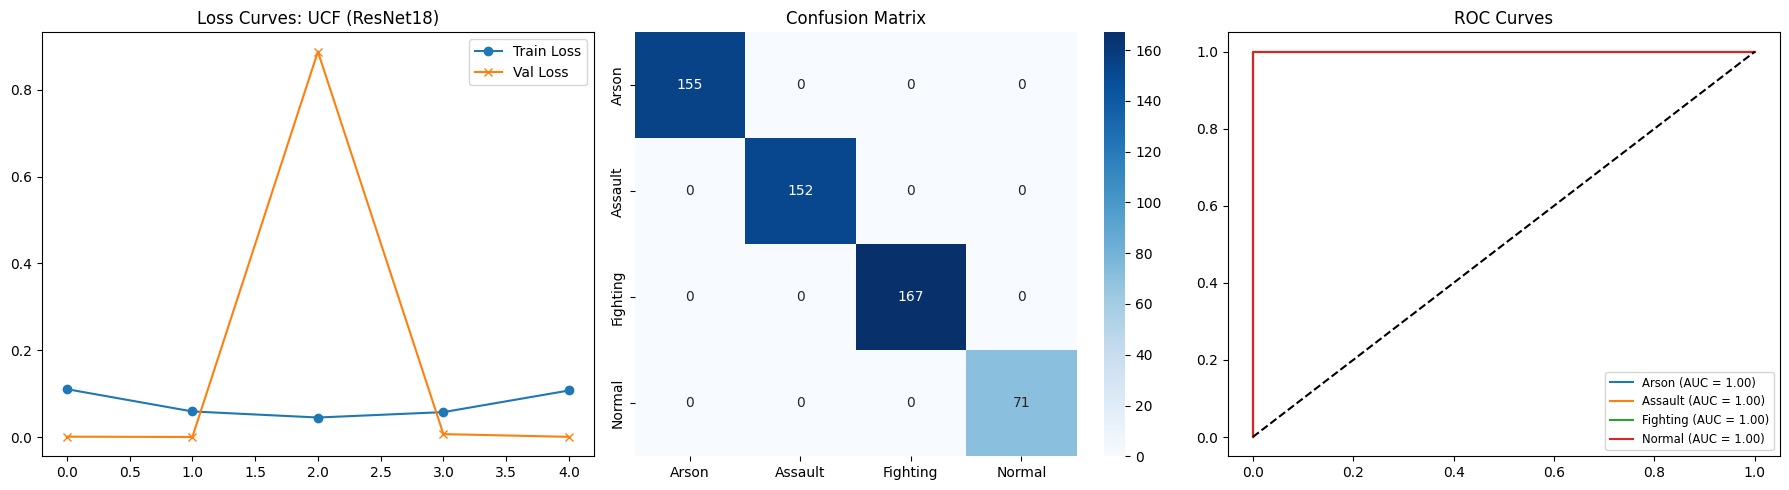


📋 Classification Report:
              precision    recall  f1-score   support

       Arson       1.00      1.00      1.00       155
     Assault       1.00      1.00      1.00       152
    Fighting       1.00      1.00      1.00       167
      Normal       1.00      1.00      1.00        71

    accuracy                           1.00       545
   macro avg       1.00      1.00      1.00       545
weighted avg       1.00      1.00      1.00       545


🚀 STARTING RESEARCH MODULE: UCF (mobilenet)
Epoch 1 | T-Loss: 0.1352 | V-Loss: 0.0000 | Acc: 1.0000
Epoch 2 | T-Loss: 0.1073 | V-Loss: 0.6739 | Acc: 0.8385
Epoch 3 | T-Loss: 0.0938 | V-Loss: 0.0001 | Acc: 1.0000
Epoch 4 | T-Loss: 0.0623 | V-Loss: 0.0004 | Acc: 1.0000
🛑 Early Stopping triggered at epoch 4!


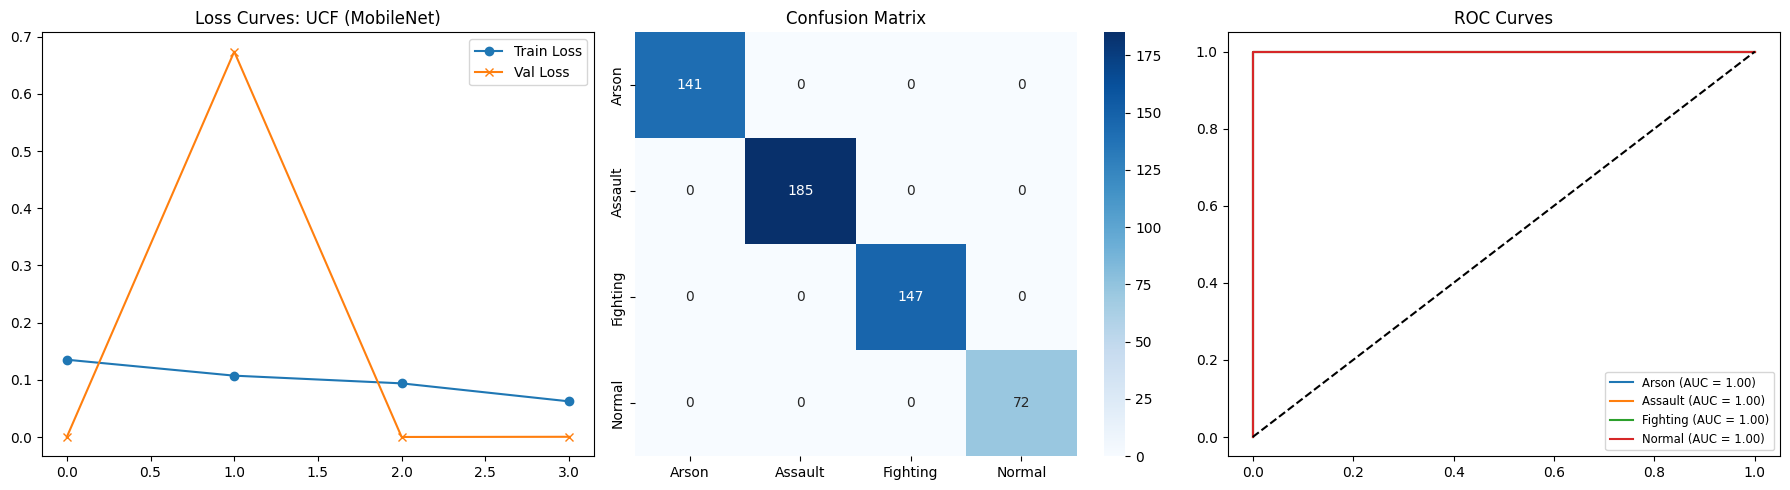


📋 Classification Report:
              precision    recall  f1-score   support

       Arson       1.00      1.00      1.00       141
     Assault       1.00      1.00      1.00       185
    Fighting       1.00      1.00      1.00       147
      Normal       1.00      1.00      1.00        72

    accuracy                           1.00       545
   macro avg       1.00      1.00      1.00       545
weighted avg       1.00      1.00      1.00       545



In [ ]:
# 1. RUN RESNET18
# Change the path below to match your actual Drive folder name
model_res, hist_res, cls_res, loader_res = run_research_pipeline(
    "/content/drive/MyDrive/Anomaly_Detection/FINAL_MAJOR_PROJECT/ucf_crime", "UCF", model_type='resnet18'
)
plot_comprehensive_metrics(hist_res, model_res, loader_res, cls_res, "UCF (ResNet18)")

# 2. RUN MOBILENET (For Comparison)
model_mob, hist_mob, cls_mob, loader_mob = run_research_pipeline(
    "/content/drive/MyDrive/Anomaly_Detection/FINAL_MAJOR_PROJECT/ucf_crime", "UCF", model_type='mobilenet'
)
plot_comprehensive_metrics(hist_mob, model_mob, loader_mob, cls_mob, "UCF (MobileNet)")


🚀 STARTING RESEARCH MODULE: UCSD (resnet18)
Epoch 1 | T-Loss: 0.1377 | V-Loss: 0.0375 | Acc: 0.9844
Epoch 2 | T-Loss: 0.0102 | V-Loss: 0.0009 | Acc: 1.0000
Epoch 3 | T-Loss: 0.0078 | V-Loss: 0.0410 | Acc: 0.9844
Epoch 4 | T-Loss: 0.0041 | V-Loss: 0.0011 | Acc: 1.0000
Epoch 5 | T-Loss: 0.0274 | V-Loss: 0.4794 | Acc: 0.8688
🛑 Early Stopping triggered at epoch 5!


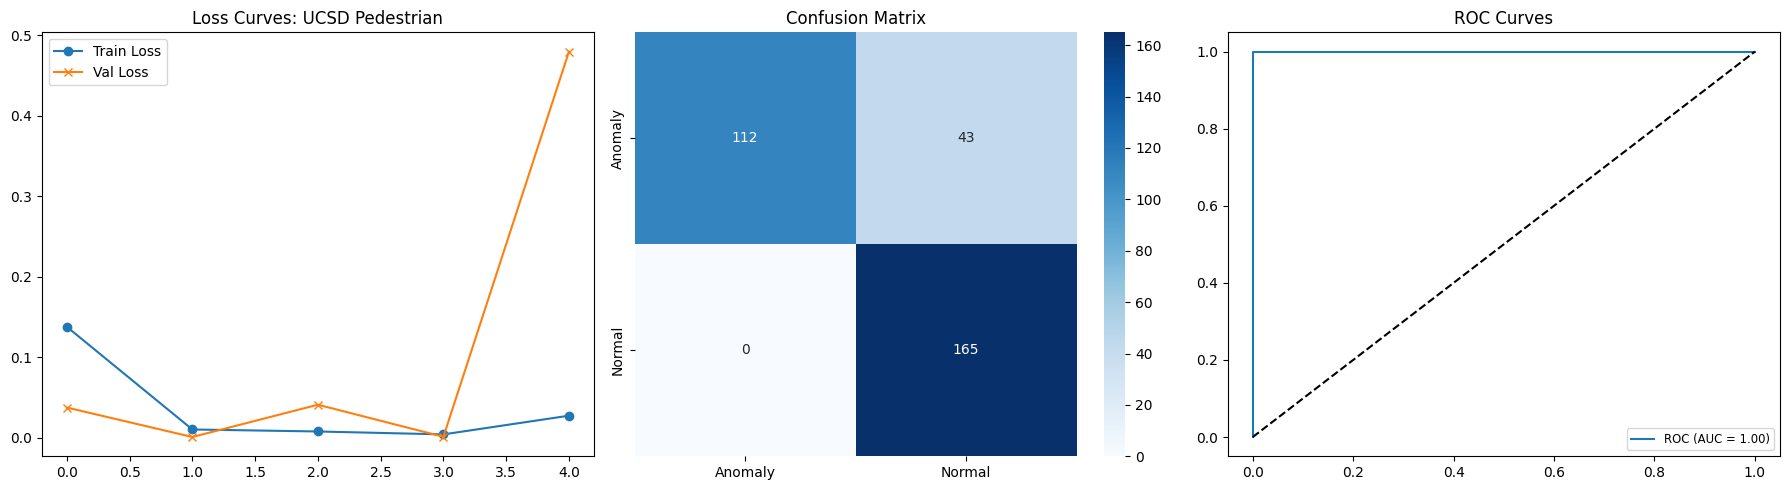


📋 Classification Report:
              precision    recall  f1-score   support

     Anomaly       1.00      0.72      0.84       155
      Normal       0.79      1.00      0.88       165

    accuracy                           0.87       320
   macro avg       0.90      0.86      0.86       320
weighted avg       0.89      0.87      0.86       320



In [ ]:
# Final Execution for UCSD
model_ucsd, hist_ucsd, cls_ucsd, loader_ucsd = run_research_pipeline(
    "/content/drive/MyDrive/Anomaly_Detection/FINAL_MAJOR_PROJECT/ucsd_ped2", "UCSD"
)
plot_comprehensive_metrics(hist_ucsd, model_ucsd, loader_ucsd, cls_ucsd, "UCSD Pedestrian")